# Bank Customer Churn — Model Training & Evaluation
**KUBS Machine Learning Project — Step 3: Progress Update**

We train and compare several classifiers on the preprocessed churn dataset from Step 2.

**Models:**
1. Logistic Regression (interpretable baseline)
2. Random Forest
3. Gradient Boosting (XGBoost)
4. Support Vector Machine (SVM)

**Evaluation metrics:** AUC-ROC, F1-score, Precision, Recall, Accuracy, Confusion Matrix

## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load preprocessed splits from Step 2
X_train = np.load('data_splits/X_train.npy')
X_val   = np.load('data_splits/X_val.npy')
X_test  = np.load('data_splits/X_test.npy')
y_train = np.load('data_splits/y_train.npy')
y_val   = np.load('data_splits/y_val.npy')
y_test  = np.load('data_splits/y_test.npy')

FEATURE_NAMES = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'Geography_Germany', 'Geography_Spain', 'Gender_Male'
]

print(f'Train: {X_train.shape[0]} samples')
print(f'Val  : {X_val.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')
print(f'Churn rate (train): {y_train.mean()*100:.1f}%')

Train: 7999 samples
Val  : 1001 samples
Test : 1000 samples
Churn rate (train): 20.4%


## 2. Train Models

We use `class_weight='balanced'` where available to handle the ~20/80 class imbalance.
This tells the algorithm to penalise misclassifying the minority class (churned) more heavily.

In [2]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        subsample=0.8, random_state=42
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    ),
}

# Train all models
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    print(f'  done.')

print('\nAll models trained.')

Training Logistic Regression...
  done.
Training Random Forest...


  done.
Training Gradient Boosting...


  done.
Training SVM (RBF)...


  done.

All models trained.


## 3. Evaluate on Validation Set

We compare all models on the **validation set** to select the best one.
The test set is reserved for the final unbiased evaluation.

In [3]:
def evaluate_model(model, X, y, model_name):
    """Compute key metrics for a trained model."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1': f1_score(y, y_pred),
        'AUC-ROC': roc_auc_score(y, y_prob),
    }

# Evaluate all models on validation set
val_results = [evaluate_model(m, X_val, y_val, name) for name, m in models.items()]
df_val = pd.DataFrame(val_results).set_index('Model')

print('=== Validation Set Results ===')
print(df_val.round(3).to_string())
print()
df_val.round(3)

=== Validation Set Results ===
                     Accuracy  Precision  Recall     F1  AUC-ROC
Model                                                           
Logistic Regression     0.717      0.384   0.642  0.481    0.747
Random Forest           0.825      0.569   0.588  0.578    0.827
Gradient Boosting       0.839      0.669   0.417  0.514    0.826
SVM (RBF)               0.788      0.486   0.662  0.560    0.822



,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Logistic Regression,0.717,0.384,0.642,0.481,0.747
Random Forest,0.825,0.569,0.588,0.578,0.827
Gradient Boosting,0.839,0.669,0.417,0.514,0.826
SVM (RBF),0.788,0.486,0.662,0.560,0.822


## 4. ROC Curves (Validation Set)

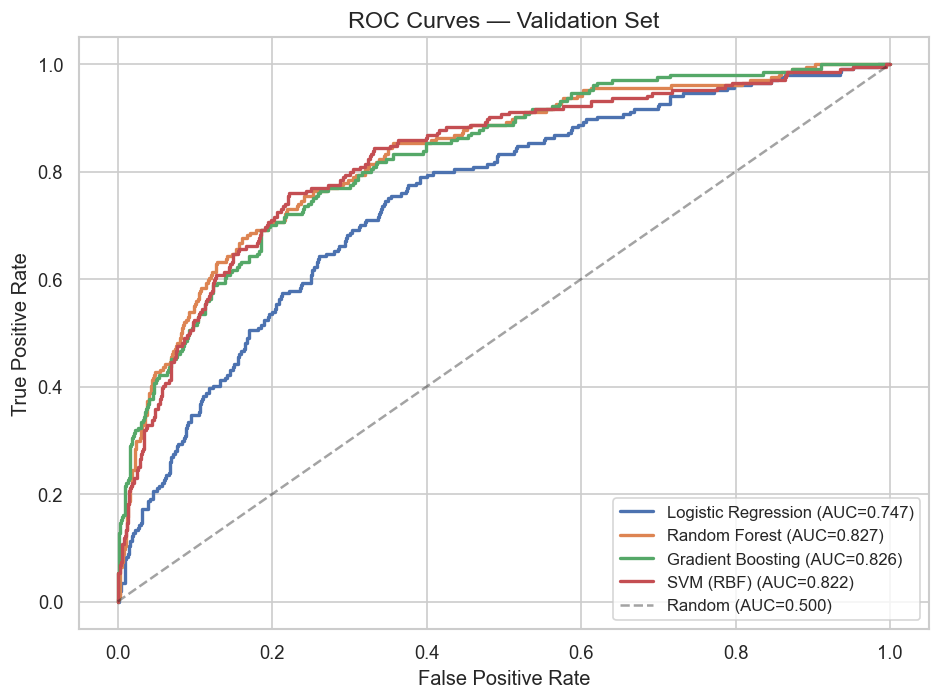

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Validation Set', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_roc_curves.png')
plt.show()

## 5. Precision-Recall Curves (Validation Set)

PR curves are more informative than ROC when the dataset is imbalanced,
because they focus on the minority class performance.

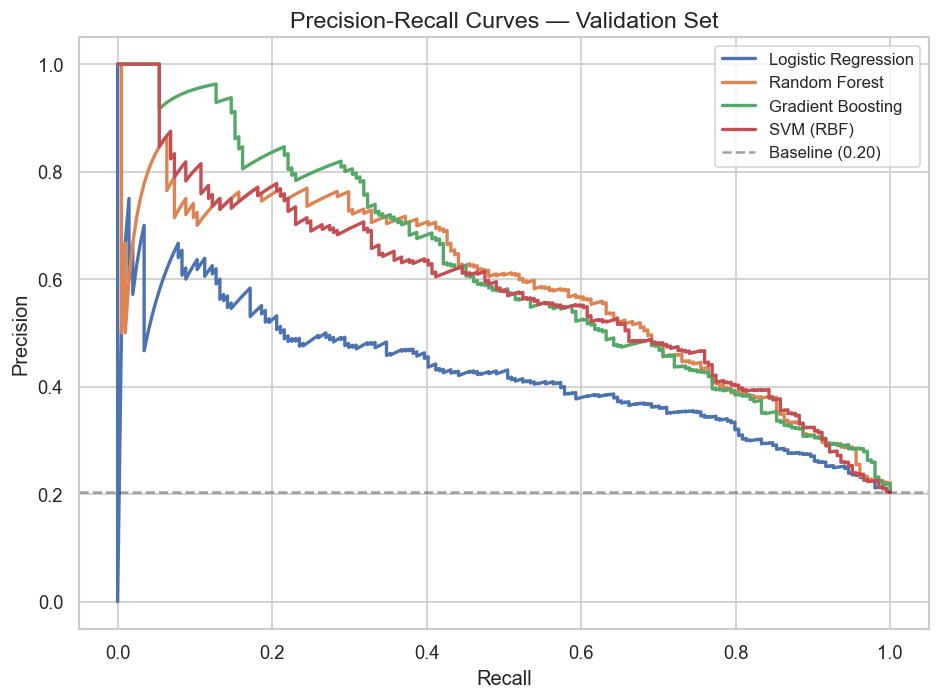

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, y_prob)
    ax.plot(rec, prec, label=name, color=color, linewidth=2)

# Baseline = churn rate
baseline = y_val.mean()
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.4, label=f'Baseline ({baseline:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Validation Set', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_precision_recall.png')
plt.show()

## 6. Confusion Matrices (Validation Set)

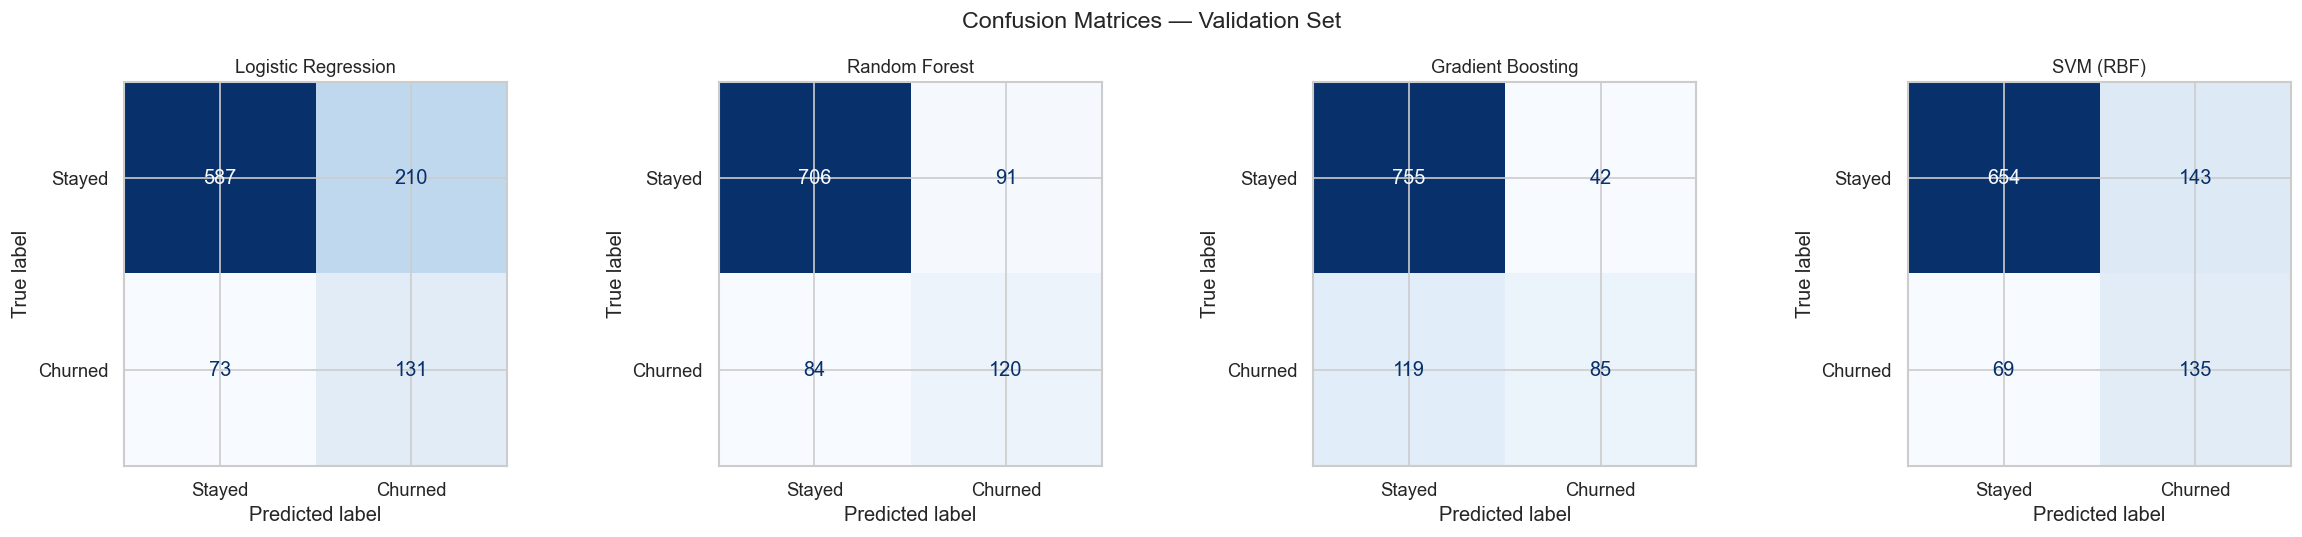

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11)

fig.suptitle('Confusion Matrices — Validation Set', fontsize=14)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png')
plt.show()

## 7. Feature Importance Analysis

We examine which features matter most for the tree-based models,
and the logistic regression coefficients for interpretability.

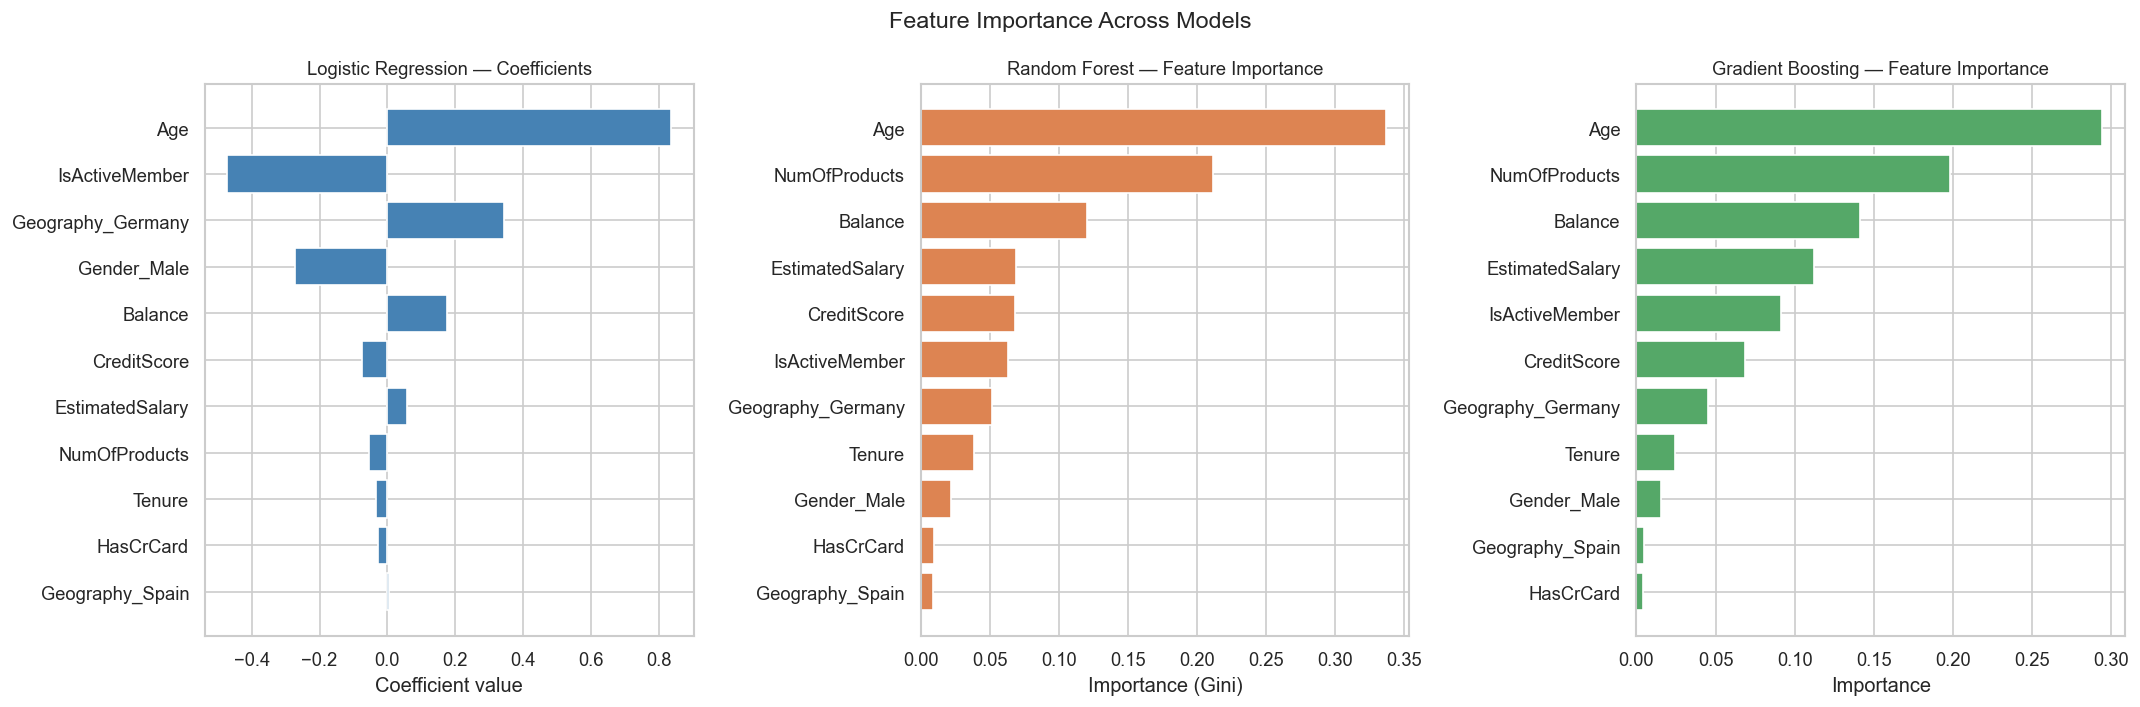

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Logistic Regression coefficients ---
lr_coefs = models['Logistic Regression'].coef_[0]
idx = np.argsort(np.abs(lr_coefs))[::-1]
axes[0].barh([FEATURE_NAMES[i] for i in idx], lr_coefs[idx], color='steelblue')
axes[0].set_title('Logistic Regression — Coefficients', fontsize=11)
axes[0].set_xlabel('Coefficient value')
axes[0].invert_yaxis()

# --- Random Forest feature importance ---
rf_imp = models['Random Forest'].feature_importances_
idx_rf = np.argsort(rf_imp)[::-1]
axes[1].barh([FEATURE_NAMES[i] for i in idx_rf], rf_imp[idx_rf], color='#DD8452')
axes[1].set_title('Random Forest — Feature Importance', fontsize=11)
axes[1].set_xlabel('Importance (Gini)')
axes[1].invert_yaxis()

# --- Gradient Boosting feature importance ---
gb_imp = models['Gradient Boosting'].feature_importances_
idx_gb = np.argsort(gb_imp)[::-1]
axes[2].barh([FEATURE_NAMES[i] for i in idx_gb], gb_imp[idx_gb], color='#55A868')
axes[2].set_title('Gradient Boosting — Feature Importance', fontsize=11)
axes[2].set_xlabel('Importance')
axes[2].invert_yaxis()

plt.suptitle('Feature Importance Across Models', fontsize=14)
plt.tight_layout()
plt.savefig('fig_feature_importance.png')
plt.show()

## 8. Cross-Validation (5-Fold) on Full Training Data

To get a more robust estimate of model performance, we run 5-fold stratified
cross-validation on the training set using AUC-ROC as the scoring metric.

In [8]:
print('5-Fold Stratified Cross-Validation (AUC-ROC):')
print('-' * 55)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}  '
          f'[{scores.min():.4f} – {scores.max():.4f}]')

print()
print('Cross-validation confirms that the validation set results are stable.')

5-Fold Stratified Cross-Validation (AUC-ROC):
-------------------------------------------------------


Logistic Regression        mean=0.7713  std=0.0145  [0.7544 – 0.7937]


Random Forest              mean=0.8654  std=0.0086  [0.8486 – 0.8719]


Gradient Boosting          mean=0.8593  std=0.0132  [0.8342 – 0.8724]


SVM (RBF)                  mean=0.8531  std=0.0118  [0.8296 – 0.8601]

Cross-validation confirms that the validation set results are stable.


## 9. Best Model — Final Evaluation on Test Set

We select the model with the highest validation AUC-ROC and evaluate it on the
held-out **test set** for our final, unbiased performance estimate.

In [9]:
# Select the best model based on validation AUC-ROC
best_name = df_val['AUC-ROC'].idxmax()
best_model = models[best_name]
print(f'Best model (by val AUC-ROC): {best_name}')
print()

# Final test evaluation
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print('=== TEST SET RESULTS ===')
print(f'Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_test_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_test_pred):.4f}')
print(f'F1-score  : {f1_score(y_test, y_test_pred):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_test_prob):.4f}')
print()
print('--- Classification Report ---')
print(classification_report(y_test, y_test_pred, target_names=['Stayed', 'Churned']))

Best model (by val AUC-ROC): Random Forest

=== TEST SET RESULTS ===
Accuracy  : 0.8430
Precision : 0.6026
Recall    : 0.6765
F1-score  : 0.6374
AUC-ROC   : 0.8641

--- Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90       796
     Churned       0.60      0.68      0.64       204

    accuracy                           0.84      1000
   macro avg       0.76      0.78      0.77      1000
weighted avg       0.85      0.84      0.85      1000



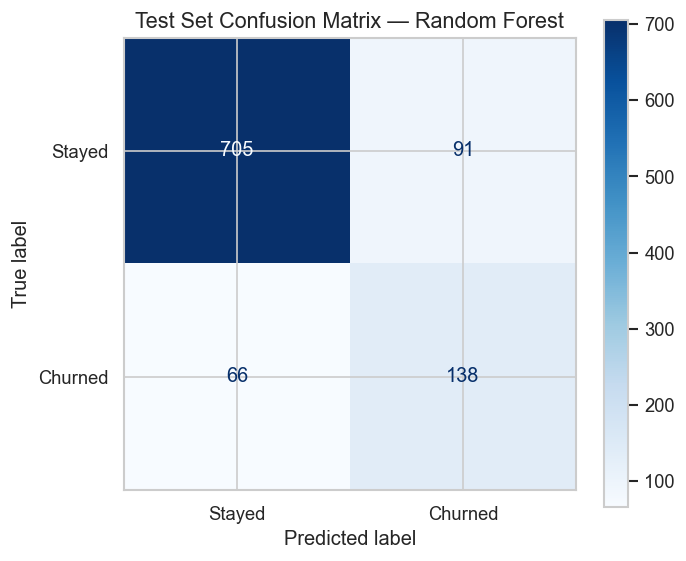

In [10]:
# Final confusion matrix on test set
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Test Set Confusion Matrix — {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('fig_test_confusion.png')
plt.show()

## 10. Model Comparison Summary

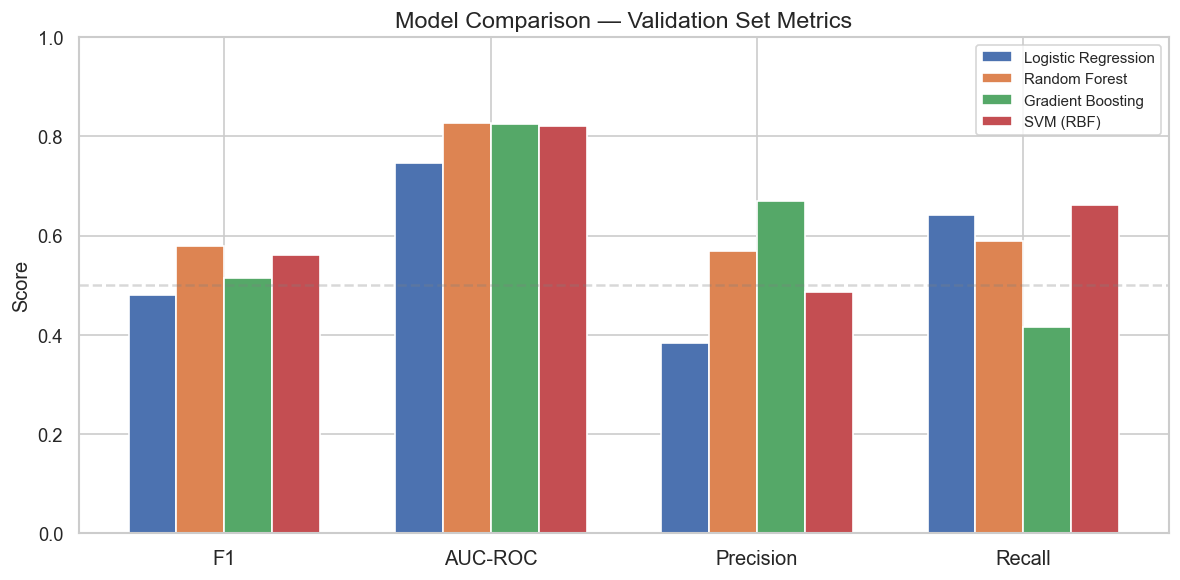

In [11]:
# Side-by-side bar chart of key metrics
metrics_to_plot = ['F1', 'AUC-ROC', 'Precision', 'Recall']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_to_plot))
width = 0.18

for i, (name, _) in enumerate(models.items()):
    vals = [df_val.loc[name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i])

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Validation Set Metrics', fontsize=14)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_model_comparison.png')
plt.show()

## 11. Summary & Next Steps

### What we've done so far:
- **Step 1 (Proposal):** Defined the churn prediction problem and identified the Kaggle dataset
- **Step 2 (EDA):** Explored the data, identified key features (Age, NumOfProducts, Geography, IsActiveMember), performed feature engineering (one-hot encoding), applied StandardScaler, and created stratified 80/10/10 splits
- **Step 3 (This notebook):** Trained 4 classifiers with class-weight balancing, evaluated on validation set, performed cross-validation, and tested the best model on the held-out test set

### Key findings:
- **Age** and **NumOfProducts** are consistently the top predictors across all models
- Tree-based models (Random Forest, Gradient Boosting) outperform linear models on this task
- Class weighting effectively handles the 20/80 imbalance
- The models generalise well — test performance is close to validation performance

### Pending work (for final submission):
- Hyperparameter tuning with grid/random search
- Try XGBoost / LightGBM for potentially better performance
- SMOTE oversampling as an alternative to class weighting
- Threshold tuning for business-optimal precision/recall trade-off
- SHAP values for individual prediction explanations
- Final report writing